In [1]:
# We load the training dataset for the 2D Navier-Stokes equations for an incompressible fluid.
# Both input and output are 2D fields with a single data channel describing the vorticity at each point.

from neuralop.data.datasets import NavierStokesDataset

dataset = NavierStokesDataset(
    root_dir="/content/data", train_resolution=128, n_train=1000, batch_size=32,
    n_tests=[50], test_batch_sizes=[32], test_resolutions=[128]
)

Loading test db for resolution 128 with 50 samples 


In [2]:
# We prepare the training and test data to be delivered in mini-batches
import torch
from torch.utils.data import DataLoader

# We create the training DataLoader, shuffling the data (shuffle=True)
train_loader = DataLoader(dataset.train_db,batch_size=32,shuffle=True)

# We create the test DataLoaders. Since 'test_dbs' is a dictionary, # we request the dataset with $128 	imes 128$ resolution that you downloaded.
test_loader_128 = DataLoader(dataset.test_dbs[128],batch_size=32,shuffle=False)

# The Trainer expects a dictionary of DataLoaders indexed by their resolution:
test_loaders = {
    128: test_loader_128
}

In [3]:
import torch
from torch.utils.data import DataLoader

# We check the configuration and the shape of the dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch = next(iter(train_loader))

print("Forma de x:", batch["x"].shape)
print("Forma de y:", batch["y"].shape)

in_channels = batch["x"].shape[1]
out_channels = batch["y"].shape[1]

print("in_channels:", in_channels)
print("out_channels:", out_channels)
print("device:", device)

Forma de x: torch.Size([32, 1, 128, 128])
Forma de y: torch.Size([32, 1, 128, 128])
in_channels: 1
out_channels: 1
device: cuda


In [4]:
# We create an instance of the 2D FNO model
from neuralop.models import FNO

model = FNO(n_modes=(16, 16), hidden_channels=32,
            in_channels=in_channels, out_channels=out_channels)

model = model.to(device)

In [5]:
# We define the loss functions and metrics

from neuralop.losses import LpLoss

loss_fn = LpLoss(d=2, p=2)

def relative_l2_error(pred, target, eps=1e-12):

    # Mean relative L2 error per batch.

    pred_flat = pred.reshape(pred.shape[0], -1)
    target_flat = target.reshape(target.shape[0], -1)

    numerator = torch.norm(pred_flat - target_flat, p=2, dim=1)
    denominator = torch.norm(target_flat, p=2, dim=1)

    return torch.mean(numerator / (denominator + eps))


def compute_metrics(pred, target):

    # We compute several useful metrics to analyze the model.

    mse = torch.mean((pred - target) ** 2)
    mae = torch.mean(torch.abs(pred - target))
    rmse = torch.sqrt(mse)
    rel_l2 = relative_l2_error(pred, target)

    return {
        "mse": mse.item(),
        "mae": mae.item(),
        "rmse": rmse.item(),
        "rel_l2": rel_l2.item()
    }

In [6]:
#Optimizer and scheduler (gradually reduces the learning rate)

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

n_epochs = 100

optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

In [7]:
import os
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

history = []

best_eval_l2 = float("inf")
best_model_path = "fno_navier_stokes_modelo.pt"

for epoch in range(n_epochs):
    start_time = time.time()

    # TRAIN

    model.train()

    train_loss_total = 0.0
    train_mse_total = 0.0
    train_mae_total = 0.0
    train_rmse_total = 0.0
    train_l2_total = 0.0
    train_samples = 0

    for batch in train_loader:
        x = batch["x"].float().to(device)
        y = batch["y"].float().to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        batch_size = x.shape[0]
        train_samples += batch_size

        metrics = compute_metrics(pred.detach(), y)

        train_loss_total += loss.item() * batch_size
        train_mse_total += metrics["mse"] * batch_size
        train_mae_total += metrics["mae"] * batch_size
        train_rmse_total += metrics["rmse"] * batch_size
        train_l2_total += metrics["rel_l2"] * batch_size

    scheduler.step()

    train_loss_avg = train_loss_total / train_samples
    train_mse_avg = train_mse_total / train_samples
    train_mae_avg = train_mae_total / train_samples
    train_rmse_avg = train_rmse_total / train_samples
    train_l2_avg = train_l2_total / train_samples

    # TEST

    model.eval()

    eval_loss_total = 0.0
    eval_mse_total = 0.0
    eval_mae_total = 0.0
    eval_rmse_total = 0.0
    eval_l2_total = 0.0
    eval_samples = 0

    with torch.no_grad():
        for batch in test_loader_128:
            x = batch["x"].float().to(device)
            y = batch["y"].float().to(device)

            pred = model(x)

            val_loss = loss_fn(pred, y)

            batch_size = x.shape[0]
            eval_samples += batch_size

            metrics = compute_metrics(pred, y)

            eval_loss_total += val_loss.item() * batch_size
            eval_mse_total += metrics["mse"] * batch_size
            eval_mae_total += metrics["mae"] * batch_size
            eval_rmse_total += metrics["rmse"] * batch_size
            eval_l2_total += metrics["rel_l2"] * batch_size

    eval_loss_avg = eval_loss_total / eval_samples
    eval_mse_avg = eval_mse_total / eval_samples
    eval_mae_avg = eval_mae_total / eval_samples
    eval_rmse_avg = eval_rmse_total / eval_samples
    eval_l2_avg = eval_l2_total / eval_samples

    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]["lr"]


    # SAVE METRICS

    row = {
        "epoch": epoch,
        "time_sec": epoch_time,
        "lr": current_lr,

        "train_loss_lp": train_loss_avg,
        "train_rel_l2": train_l2_avg,
        "train_mse": train_mse_avg,
        "train_mae": train_mae_avg,
        "train_rmse": train_rmse_avg,

        "eval_loss_lp": eval_loss_avg,
        "eval_rel_l2": eval_l2_avg,
        "eval_mse": eval_mse_avg,
        "eval_mae": eval_mae_avg,
        "eval_rmse": eval_rmse_avg,
    }

    history.append(row)

    # Save CSV at each epoch
    history_df = pd.DataFrame(history)
    history_df.to_csv("training_history.csv", index=False)

    # Save best model based on test relative L2 error
    if eval_l2_avg < best_eval_l2:
        best_eval_l2 = eval_l2_avg
        torch.save(model.state_dict(), best_model_path)

    print(
        f"[{epoch}] "
        f"time={epoch_time:.2f}s | "
        f"train_l2={train_l2_avg:.4f} | "
        f"eval_l2={eval_l2_avg:.4f} | "
        f"train_mse={train_mse_avg:.6f} | "
        f"eval_mse={eval_mse_avg:.6f}"
    )

print("Entrenamiento terminado.")
print(f"Mejor modelo guardado en: {best_model_path}")
print("Historial guardado en: training_history.csv")

[0] time=7.43s | train_l2=0.9513 | eval_l2=0.6146 | train_mse=0.451868 | eval_mse=0.191769
[1] time=5.30s | train_l2=0.5493 | eval_l2=0.5140 | train_mse=0.151545 | eval_mse=0.133581
[2] time=5.32s | train_l2=0.5163 | eval_l2=0.5064 | train_mse=0.132760 | eval_mse=0.130037
[3] time=5.36s | train_l2=0.5011 | eval_l2=0.4722 | train_mse=0.124957 | eval_mse=0.112397
[4] time=5.38s | train_l2=0.4186 | eval_l2=0.3497 | train_mse=0.087921 | eval_mse=0.062542
[5] time=5.42s | train_l2=0.3138 | eval_l2=0.2750 | train_mse=0.049973 | eval_mse=0.039966
[6] time=5.44s | train_l2=0.2465 | eval_l2=0.2370 | train_mse=0.031087 | eval_mse=0.029644
[7] time=5.43s | train_l2=0.2057 | eval_l2=0.1936 | train_mse=0.021877 | eval_mse=0.020468
[8] time=5.54s | train_l2=0.1779 | eval_l2=0.1760 | train_mse=0.016541 | eval_mse=0.017026
[9] time=5.42s | train_l2=0.1613 | eval_l2=0.1589 | train_mse=0.013719 | eval_mse=0.014040
[10] time=5.43s | train_l2=0.1477 | eval_l2=0.1588 | train_mse=0.011604 | eval_mse=0.01383

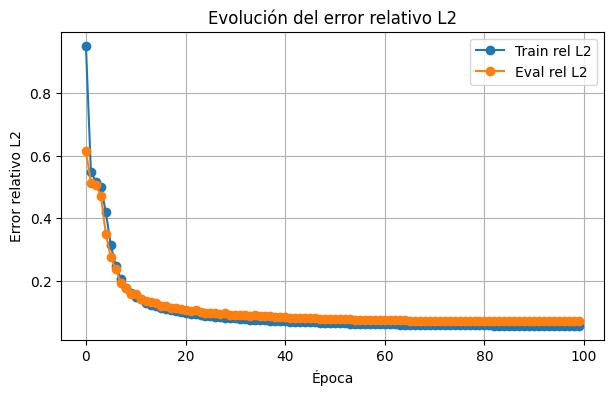

In [8]:
#Plot metrics
history_df = pd.read_csv("training_history.csv")

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_rel_l2"], marker="o", label="Train rel L2")
plt.plot(history_df["epoch"], history_df["eval_rel_l2"], marker="o", label="Eval rel L2")
plt.xlabel("Época")
plt.ylabel("Error relativo L2")
plt.title("Evolución del error relativo L2")
plt.legend()
plt.grid(True)
plt.show()

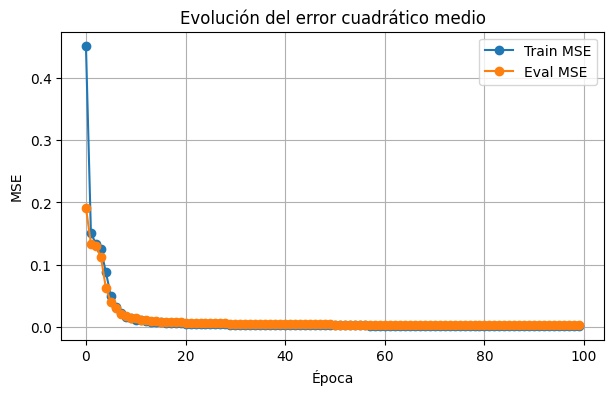

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_mse"], marker="o", label="Train MSE")
plt.plot(history_df["epoch"], history_df["eval_mse"], marker="o", label="Eval MSE")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución del error cuadrático medio")
plt.legend()
plt.grid(True)
plt.show()

Error relativo L2 de la muestra 0: 0.0660


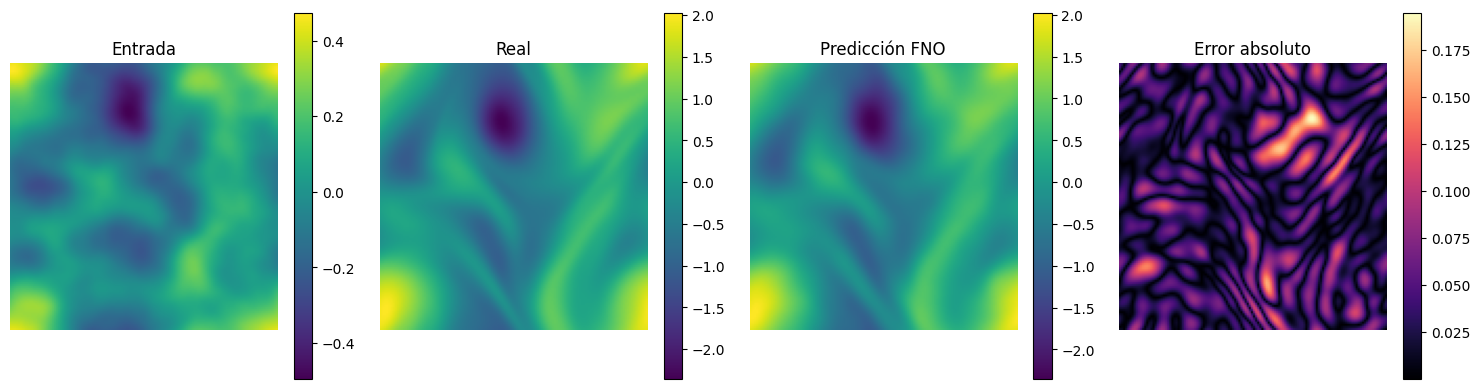

In [10]:
# We make a prediction using the trained model
import torch
import matplotlib.pyplot as plt

indice = 0  # cambia entre 0 y 49

sample = dataset.test_dbs[128][indice]

x = sample["x"].unsqueeze(0).float().to(device)
y = sample["y"].unsqueeze(0).float().to(device)

model.eval()

with torch.no_grad():
    pred = model(x)

x_img = x[0, 0].detach().cpu()
y_img = y[0, 0].detach().cpu()
pred_img = pred[0, 0].detach().cpu()
err_img = torch.abs(pred_img - y_img)

rel_l2 = torch.norm(pred_img - y_img) / torch.norm(y_img)
print(f"Error relativo L2 de la muestra {indice}: {rel_l2.item():.4f}")

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_img, cmap="viridis")
plt.title("Entrada")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(y_img, cmap="viridis")
plt.title("Real")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_img, cmap="viridis")
plt.title("Predicción FNO")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(err_img, cmap="magma")
plt.title("Error absoluto")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# This function applies the model sequentially: it first predicts from the initial image
# and then uses each prediction as input to estimate the next state.

def predecir_estados_sucesivos(model, x0, n_steps, device="cpu"):
    """
    Predicts a future sequence using the model in an autoregressive manner.

    x0:
        Tensor [B, 1, 128, 128]

    Returns:
        Tensor [B, n_steps, 128, 128]
    """
    model.eval()

    x = x0.float().to(device)
    preds = []

    with torch.no_grad():
        for _ in range(n_steps):
            pred = model(x)          # [B, 1, 128, 128]
            preds.append(pred.cpu()) # save prediction
            x = pred                 # the prediction will be the new input

    preds = torch.cat(preds, dim=1)  # [B, 10, 128, 128]
    return preds

In [12]:
# We execute predecir_estados_sucesivos()

# Fetch a batch from the test dataset
indice = 0  # this number varies between 0 and 49

sample = dataset.test_dbs[128][indice]

x0 = sample["x"].unsqueeze(0)  # [1, 1, 128, 128]
y_real = sample["y"].unsqueeze(0)

print("x0:", x0.shape)
print("y_real:", y_real.shape)

preds_10 = predecir_estados_sucesivos(model=model, x0=x0, n_steps=5, device=device)

print("Forma de la secuencia predicha:", preds_10.shape)

x0: torch.Size([1, 1, 128, 128])
y_real: torch.Size([1, 1, 128, 128])
Forma de la secuencia predicha: torch.Size([1, 5, 128, 128])


In [ ]:
#The last one means:
#32 examples
#10 predicted time steps
#128 x 128

In [13]:
import os
import torch
import matplotlib.pyplot as plt
import imageio.v2 as imageio

def crear_gif_rollout(
    preds,
    x0=None,
    ejemplo=0,
    gif_name="rollout_fno.gif",
    duration=1000):
    """
    GIF with automatic scaling on each frame.
    It will look like an individual image made with plt.imshow(campo, cmap="viridis").
    """

    os.makedirs("gif_frames", exist_ok=True)
    frames = []

    campos = []

    if x0 is not None:
        campos.append(("Estado inicial", x0[ejemplo, 0].detach().cpu()))

    for t in range(preds.shape[1]):
        campos.append((f"Predicción t+{t+1}", preds[ejemplo, t].detach().cpu()))

    for i, (title, campo) in enumerate(campos):
        plt.figure(figsize=(5, 4))

        # IMPORTANT: without vmin and vmax
        plt.imshow(campo, cmap="viridis")

        plt.title(title)
        plt.colorbar()
        plt.axis("off")
        plt.tight_layout()

        frame_path = f"gif_frames/frame_{i:03d}.png"
        plt.savefig(frame_path, dpi=120)
        plt.close()

        frames.append(imageio.imread(frame_path))

    imageio.mimsave(gif_name, frames, duration=duration)
    print(f"GIF guardado como: {gif_name}")

In [14]:
crear_gif_rollout(
    preds=preds_10,
    x0=x0,
    ejemplo=0,
    gif_name="predicción_fno.gif",
    duration=1000
)

GIF guardado como: predicción_fno.gif


In [15]:
def diagnosticar_rollout(model, x0, n_steps=10, device="cpu"):
    model.eval()
    x = x0.float().to(device)

    print("Paso inicial")
    print("x min:", x.min().item(), "x max:", x.max().item(), "norm:", torch.norm(x).item())

    with torch.no_grad():
        for t in range(n_steps):
            pred = model(x)

            print(f"\nPaso {t+1}")
            print("pred min:", pred.min().item())
            print("pred max:", pred.max().item())
            print("pred mean:", pred.mean().item())
            print("pred norm:", torch.norm(pred).item())

            x = pred

In [16]:
indice = 0
sample = dataset.test_dbs[128][indice]

x0 = sample["x"].unsqueeze(0).float().to(device)

diagnosticar_rollout(
    model=model,
    x0=x0,
    n_steps=10,
    device=device
)

Paso inicial
x min: -0.49507734179496765 x max: 0.471683144569397 norm: 20.39707374572754

Paso 1
pred min: -2.3526127338409424
pred max: 2.0137546062469482
pred mean: 0.003162338398396969
pred norm: 95.24215698242188

Paso 2
pred min: -6.766077995300293
pred max: 7.664669990539551
pred mean: 0.001127626746892929
pred norm: 333.55291748046875

Paso 3
pred min: -15.143325805664062
pred max: 19.598543167114258
pred mean: 0.09037993103265762
pred norm: 874.9580078125

Paso 4
pred min: -37.730010986328125
pred max: 50.458038330078125
pred mean: 0.4362632632255554
pred norm: 1991.800537109375

Paso 5
pred min: -83.52275085449219
pred max: 116.97972106933594
pred mean: 0.3491741716861725
pred norm: 4393.58837890625

Paso 6
pred min: -183.09255981445312
pred max: 260.0287780761719
pred mean: 1.5040416717529297
pred norm: 9347.7666015625

Paso 7
pred min: -375.58624267578125
pred max: 587.698486328125
pred mean: 4.094402313232422
pred norm: 20039.630859375

Paso 8
pred min: -803.2420654296875


In [17]:
print(model)

FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([32, 32, 16, 9]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(32, 32, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(32, 16, kernel_size=(1,), stride=(1,))
          (1): Conv1d(16, 32, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(64, 1, kernel_size=(